This notebook is a continuation of `Electrodeposition.ipynb`. Please run that notebook first to generate `Electrodeposition_data.pkl` before continuing. The cell below will import the required packages and restore the generated data.

In [1]:
import scm.pyzacros as pz

import random
random_seed = 100
random.seed(random_seed)

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.animation as animation
plt.rcParams['figure.figsize'] = [7, 7]

from IPython.display import HTML

import dill
with open('Electrodeposition_data.pkl', 'rb') as f: data = dill.load(f)
globals().update(data)

The Inlet Model: Simulating Diffusion-Limited Growth (Optional)
---------------------------------------------------------------

We can also model a system with a distinct concentration gradient by defining an explicit ion inlet rather than a uniform background reservoir.

In the code below, we define a new species I (Inlet). We initialize the lattice with our standard solid M electrode at the bottom (dark blue) and a solid line of I sites at the top (yellow). We also keep our initial 20% random seeding of M+ ions in the electrolyte solution.

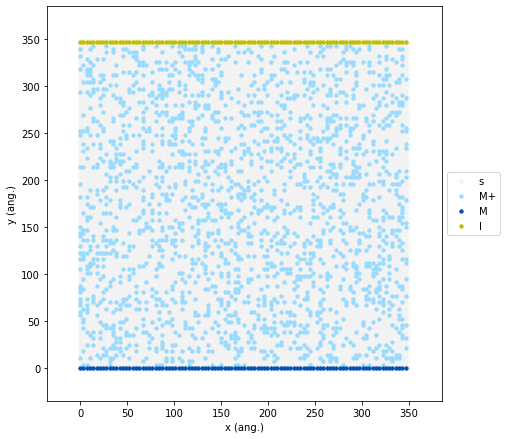

<AxesSubplot: xlabel='x (ang.)', ylabel='y (ang.)'>

In [2]:
I = pz.Species('I', denticity=1, kind=pz.Species.SURFACE, mass=1.0)
I_cluster = pz.Cluster( label='I', site_types=['s'], species=[I] )

initial_state = pz.LatticeState( lattice, [M, Mp, s], initial=True )

for sid in range(0,100*100,100):
    initial_state.fill_site( sid, M )
    initial_state.fill_site( sid-1, I )
                
initial_state.fill_sites_random('s', Mp, 0.2)

initial_state.plot( marker_size=2.5, markers=['o', 'o', 'o'],
                    colors=['#98dbff','#0053b6', 'y'], lattice_color='0.95' )

In this geometry, new `M+` ions are continuously pumped into the system by the top yellow layer. This means they must physically diffuse across the entire simulation box to reach the bottom electrode before they can be reduced.

To implement this, we define a new elementary reaction where our fictitious `Mg` gas can only generate an `M+` ion on an empty site (`s`) if it is directly adjacent to an Inlet site (`I`). Notice that we also increased our scaling fraction to `f_A = 0.02`. Because ions are now only entering the system from a single boundary row rather than uniformly across the whole grid, we need a higher local injection rate to maintain a steady overall flux.

In [3]:
Mg = pz.Species('Mg', gas_energy=0.0, mass=1.0)

f_A = 0.02
k_A = f_A*k_R

MpAddIons = pz.ElementaryReaction(
                  label='MpAddIons',
                  site_types=['s', 's'],
                  initial=[I, s, Mg],
                  final=[I, Mp],
                  neighboring=[(0, 1)],
                  reversible=False,
                  pre_expon=k_A,
                  activation_energy=0.0)

Finally, we update our `cluster_expansion` to include the new inlet species, our `mechanism` with the new `MpAddIons` reaction and execute the updated ZacrosJob. To ensure the injected `M+` ions have enough time to diffuse from the top boundary down to the working electrode, we increased the time step by a factor of 4 (previously $3\cdot 10^{-8}$ s), which indirectly increased the total simulation time. Perfect time for a lunch break! On a typical laptop, this calculation will take around an hour to wrap up.

In [4]:
cluster_expansion = [M_cluster, Mp_cluster, I_cluster]
mechanism = [MpDiffusion, MpReduction, MTerraceDiffusion, MDiffusionAwayFromStep, MpAddIons]

dt = 1.2e-7
sett.max_time = 15*dt
sett.snapshots = ('time', dt)
sett.process_statistics = ('time', dt)
sett.species_numbers = ('time', 0.25*dt)

job = pz.ZacrosJob(
        settings=sett,
        lattice=lattice,
        mechanism=mechanism,
        cluster_expansion=cluster_expansion,
        initial_state=initial_state
)

results = job.run()

[18.03|08:35:48] JOB plamsjob STARTED
[18.03|08:35:50] JOB plamsjob RUNNING
[18.03|09:40:41] JOB plamsjob FINISHED
[18.03|09:40:41] JOB plamsjob SUCCESSFUL


We have successfully run our directional model! First, let's take a look to the population numbers:

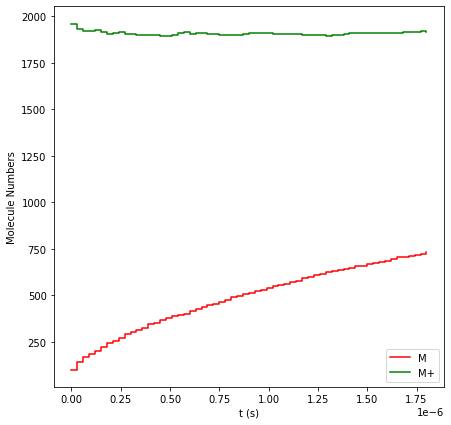

<AxesSubplot: xlabel='t (s)', ylabel='Molecule Numbers'>

In [5]:
results.plot_molecule_numbers(['M', 'M+'])

The green line shows that our new injection rate (`f_A = 0.02`) perfectly balances the reduction rate, keeping the overall M+ concentration steady while the solid `M` film grows.

Now, lets see the final spatial distribution of our deposited film:

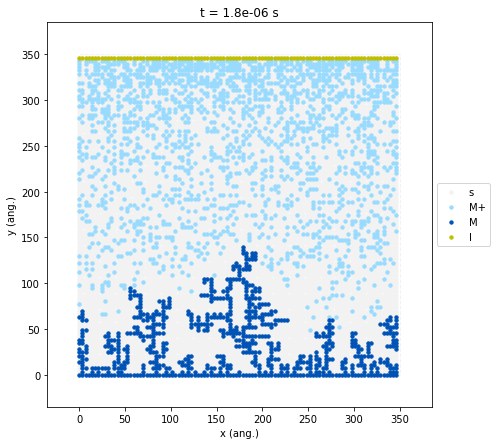

<AxesSubplot: title={'center': 't = 1.8e-06 s'}, xlabel='x (ang.)', ylabel='y (ang.)'>

In [6]:
results.plot_lattice_states( results.lattice_states()[-1], marker_size=2.5, markers=['o', 'o', 'o'],
                             colors=['#98dbff', '#0053b6', 'y'], lattice_color='0.95' )

By introducing a physical distance between the ion source (the `I` inlet at the top) and the reduction surface (the electrode at the bottom), the simulation naturally develops a concentration gradient. The `M+` species (light blue) is highly concentrated near the inlet but significantly depleted near the growth front. Furthermore, we can clearly observe localized depletion zones around the dendrite tips. This indicates a diffusion-limited growth regime. The highest peaks grow so fast that they consume all the nearby ions before those ions can travel down into the lower areas. Because the valleys are left "starved", an even film cannot form, which just causes the dendrites to grow further out of control.

Now, just for fun, let's create an animation to watch the dendritic morphology evolve over time!

In [7]:
fig, ax = plt.subplots()

frames = []
results.plot_lattice_states( results.lattice_states(), show=False, marker_size=2.5,
                             markers=['o', 'o', 'o'], colors=['#98dbff', '#0053b6', 'y'],
                             lattice_color='0.95', frames=frames )

ani = animation.ArtistAnimation(fig, frames, interval=500, blit=True)
plt.close(fig) # prevent extra static figure display in notebook

HTML(ani.to_jshtml())